# 02 — Supervised fine-tuning (SFT + LoRA)

The base model does not hold a dialogue: it completes text. Fine-tuning teaches it two things
at once, the agent's **format** and the triage **task**.

This notebook covers the format trap that cost the most, the comparison of settings, and the
convergence of the run that was kept.

In [1]:
import json
import pathlib

import pandas as pd

from clinical_triage.config import MODEL, PATHS

pd.set_option("display.max_colwidth", 90)


def read(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


tuning = read(PATHS.reports / "training" / "hyperparameter_comparison.json")
sft = read(PATHS.reports / "training" / "sft.json")
print("base model:", MODEL.base_model)

modele de base : Qwen/Qwen3-1.7B-Base


## 1. The format trap

Three silent mechanisms made the model learn a format that inference never reproduced, and the
third only appeared once the first two were believed fixed.

**The first.** A dataset that exposes a `messages` column is detected as conversational by the
training library, which re-serialises it with the model's **native** dialogue template. Qwen3's
inserts a `<think></think>` block in front of the assistant's answer:

In [2]:
from transformers import AutoTokenizer

from clinical_triage.prompts import build_messages, format_chatml, prepare_tokenizer

messages = build_messages("Douleur thoracique depuis 20 minutes.")
exchange = messages + [{"role": "assistant", "content": "Niveau de priorité : URGENCE_VITALE"}]

tokenizer = AutoTokenizer.from_pretrained(MODEL.base_model)
native = tokenizer.apply_chat_template(exchange, tokenize=False)
print("The model's native template, end of the text:")
print(repr(native[-160:]))

Gabarit natif du modele, fin du texte :
'm_end|>\n<|im_start|>user\nDouleur thoracique depuis 20 minutes.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nNiveau de priorite : URGENCE_VITALE<|im_end|>\n'


In [3]:
end_token_id = prepare_tokenizer(tokenizer)
project = format_chatml(exchange)
print("The project's template, end of the text:")
print(repr(project[-160:]))
print()
print(
    "both templates now agree:",
    tokenizer.apply_chat_template(exchange, tokenize=False) == project,
)

Gabarit du projet, fin du texte :
'ne vital engagé.<|im_end|>\n<|im_start|>user\nDouleur thoracique depuis 20 minutes.<|im_end|>\n<|im_start|>assistant\nNiveau de priorite : URGENCE_VITALE<|im_end|>\n'

les deux gabarits coincident desormais : True


**The second.** The tokenizer of `Qwen3-1.7B-Base` ships with `<|endoftext|>` as its
end-of-sequence token, while the format it is taught ends on `<|im_end|>`. The model had no
**declared** token with which to say it had finished.

In [4]:
fresh = AutoTokenizer.from_pretrained(MODEL.base_model)
print(f"factory end token : {fresh.eos_token} (id {fresh.eos_token_id})")
print(f"format end token  : <|im_end|> (id {end_token_id})")
print(f"corrected end token : {tokenizer.eos_token} (id {tokenizer.eos_token_id})")

jeton de fin d'usine  : <|endoftext|> (id 151643)
jeton de fin du format : <|im_end|> (id 151645)
jeton de fin corrige   : <|im_end|> (id 151645)


Correcting those two takes two gestures, applied once and propagated everywhere: install the
project's template on the tokenizer, and declare `<|im_end|>` as the end of sequence. The
corrected tokenizer is saved **with the merged model**: whatever engine loads it afterwards
halts where it should, and the caller has nothing to set.

The dataset consequently exposes `prompt` and `completion` instead of `messages`, which has the
further advantage of computing the loss on the answer alone, with no home-made collator.

**And yet the model still did not stop.** The rest of this notebook shows why.

In [5]:
example = json.loads((PATHS.data_processed / "sft_train.jsonl").open(encoding="utf-8").readline())
print("columns:", sorted(example))
print()
print("prompt (end) :", repr(example["prompt"][-80:]))
print("completion   :", repr(example["completion"][:120]))

colonnes : ['antecedents', 'completion', 'confiance', 'constantes', 'lang', 'level', 'presentation_id', 'prompt', 'source', 'symptomes', 'user_turn']

prompt (fin)  : 'uté.\nQuel est le niveau de priorité de triage ?<|im_end|>\n<|im_start|>assistant\n'
completion    : 'Niveau de priorité : URGENCE_VITALE\nJustification : Trouble de la conscience avec signes adrénergiques chez un patient s'


## 2. The third trap: a token the model cannot produce

Tuning the hyper-parameters returned an impossible result: **0.000 clean stops across the four
settings**, to the unit, while triage accuracy passed 0.85. An undertrained model gives a low
rate, not an exact zero repeated four times.

The measurement was checked, and the generation budget too: the expected answers run to about a
hundred tokens against a cap of 220. That leaves the base model's weights to look at.

In [6]:
# The model is not loaded: its embedding matrix is read straight out of the weight file. A few
# hundred megabytes instead of seven gigabytes, and the numbers can be traced exactly.
import json as _json

import torch
from huggingface_hub import hf_hub_download
from safetensors import safe_open

configuration = _json.loads(
    pathlib.Path(hf_hub_download(MODEL.base_model, "config.json")).read_text(encoding="utf-8")
)
print("tie_word_embeddings:", configuration["tie_word_embeddings"])

with safe_open(hf_hub_download(MODEL.base_model, "model.safetensors"), framework="pt") as weights:
    embeddings = weights.get_tensor("model.embed_tokens.weight").float()

norms = embeddings.norm(dim=1)
print()
print(f"median norm of the vocabulary        : {norms.median():.4f}")
for name, identifier in (
    ("<|endoftext|>", 151643),
    ("<|im_start|>", 151644),
    ("<|im_end|>", 151645),
):
    print(f"norm of {name:15s} (id {identifier}) : {norms[identifier]:.4f}")

chatml = embeddings[151644:151669]
print()
print(
    "are the 25 ChatML tokens identical:",
    bool(torch.equal(chatml, chatml[0].expand_as(chatml))),
)
print("largest gap between them             :", float((chatml - chatml[0]).abs().max()))
cosine = torch.nn.functional.cosine_similarity(embeddings[151644], embeddings[151645], dim=0)
print("cosine similarity im_start / im_end  :", float(cosine))

tie_word_embeddings : True



norme mediane du vocabulaire        : 1.6223
norme de <|endoftext|>   (id 151643) : 1.8832
norme de <|im_start|>    (id 151644) : 0.3748
norme de <|im_end|>      (id 151645) : 0.3748

les 25 jetons ChatML sont-ils identiques : True
ecart maximal entre eux                 : 0.0
similarite cosinus im_start / im_end    : 1.000000238418579


The verdict is plain: the twenty-five ChatML tokens are **one and the same vector**, never
trained, and the model **ties its output head to its embeddings**, which LoRA freezes. The model
therefore cannot emit `<|im_end|>` in preference to twenty-four other tokens: they share a single
output row.

Declaring the end token repaired the *plumbing*, not the ability to produce it.

The fix is to **adapt the output head as well**. Three settings compared under an identical
protocol, 75 steps and 60 validation cases:

In [7]:
# The three settings, read from the file the experiment writes. Copying them in here would have
# frozen them at the first run.
measures = _json.loads(
    (PATHS.reports / "training" / "module_comparison.json").read_text(encoding="utf-8")
)
protocol = measures["protocol"]
print(f"protocol: {protocol['steps']} steps, {protocol['validation_cases']} validation cases")
pd.DataFrame(measures["configurations"])[
    ["configuration", "trainable_parameters", "accuracy", "clean_stops", "median_tokens"]
]

protocole : 75 pas, 60 cas de validation


,configuration,parametres_entrainables,exactitude,arrets_propres,jetons_median
0,projections seules,17432576,0.85,0.0,220
1,projections + embeddings,328597504,0.85,0.0,220
2,projections + tête de sortie,328597504,0.90,1.0,97


Training the embeddings alone achieves nothing, and that is counter-intuitive: the adaptation
library copies the module, which breaks the link with the output head, and the head stays frozen.

It is a trap peculiar to **Base** models. The Instruct variant has those tokens trained, which is
why most published LoRA recipes never meet it.

## 3. LoRA: what is really trained

Low-rank adaptation freezes the model and trains only adaptation matrices grafted onto the
attention and perceptron projections, a few million parameters. To that is added here the
**output head, trained in full**: on its own it weighs close to 311 million parameters, and
brings what is actually updated to about 14% of the model. The next section explains why that
supplement is not negotiable.

In [8]:
if sft:
    metrics = sft["metrics"]
    print(f"trained parameters : {metrics['trainable_parameters']:,}")
    print(f"total parameters   : {metrics['total_parameters']:,}")
    print(f"share trained      : {metrics['trainable_share_pct']:.2f} %")
    print()
    print(f"duration           : {metrics['duration_s'] / 60:.0f} min")
    print(f"peak GPU memory    : {metrics['peak_gpu_memory_gb']:.1f} GB")
    print(
        f"hardware           : {sft['environment']['gpu']} "
        f"({sft['environment']['gpu_memory_gb']} GB)"
    )

parametres entraines : 346 030 080
parametres totaux    : 2 377 769 984
part entrainee       : 14.55 %

duree                : 57 min
memoire GPU maximale : 7.4 Go
materiel             : NVIDIA GeForce RTX 4060 Ti (16.0 Go)


A consumer card with 16 GB is therefore enough to specialise a model of 1.7 billion parameters.
That is the main infrastructure lesson of this phase, and it governs any costing of a scale-up.

## 4. Comparing the settings

Four settings were trained under identical conditions, the same subset, the same seed and the
same number of steps, then judged on two criteria: the **validation loss**, and the **triage
accuracy** measured by generation. Those two can disagree, and when they do, it is the second
that governs what the service ships.

In [9]:
if tuning:
    table = pd.DataFrame(tuning["variants"])[
        [
            "variant",
            "lora_r",
            "learning_rate",
            "trainable_parameters",
            "eval_loss",
            "triage_accuracy",
            "clean_stop_share",
            "peak_gpu_memory_gb",
        ]
    ]
    display(table)
    print()
    print("protocol:", tuning["protocol"])
    print("setting kept:", tuning["kept"])

,variante,lora_r,learning_rate,parametres_entrainables,eval_loss,exactitude_triage,part_arrets_propres,memoire_gpu_max_go
0,r32_lr2e-4,32,0.0002,346030080,0.078211,0.833,1.000,13.09
1,r16_lr2e-4,16,0.0002,328597504,0.149130,0.800,1.000,12.36
2,r8_lr2e-4,8,0.0002,319881216,0.253622,0.783,1.000,7.13
3,r16_lr1e-4,16,0.0001,328597504,0.455252,0.733,0.983,13.55



protocole : {'exemples_entrainement': 1200, 'pas': 75, 'cas_evalues': 60, 'graine': 42}
configuration retenue : r32_lr2e-4


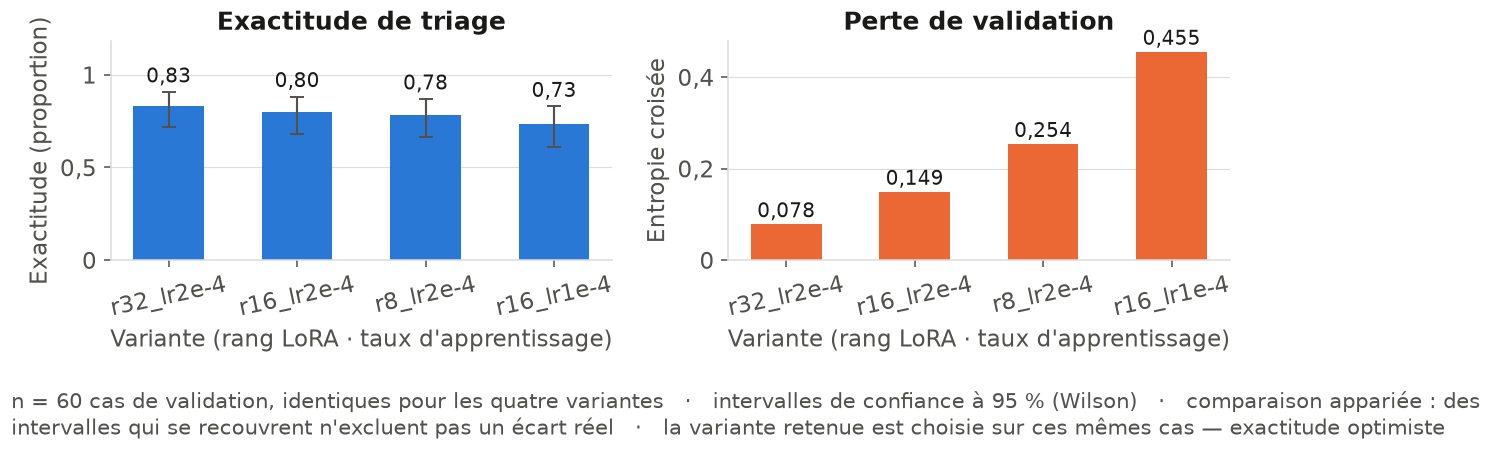

In [10]:
import matplotlib.pyplot as plt
from IPython.display import Image

from clinical_triage.reporting import figures

if tuning:
    figures.apply_style()
    path = figures.hyperparameter_tuning(tuning, PATHS.figures / "hyperparameter_tuning.png")
    plt.close("all")
    display(Image(str(path)))

The `clean_stop_share` column deserves a look: it measures the proportion of generations that
end by themselves, on the end token, and not on the token limit. A setting that learns the task
but not the stop produces answers the information system cannot use.

## 5. Convergence of the run that was kept

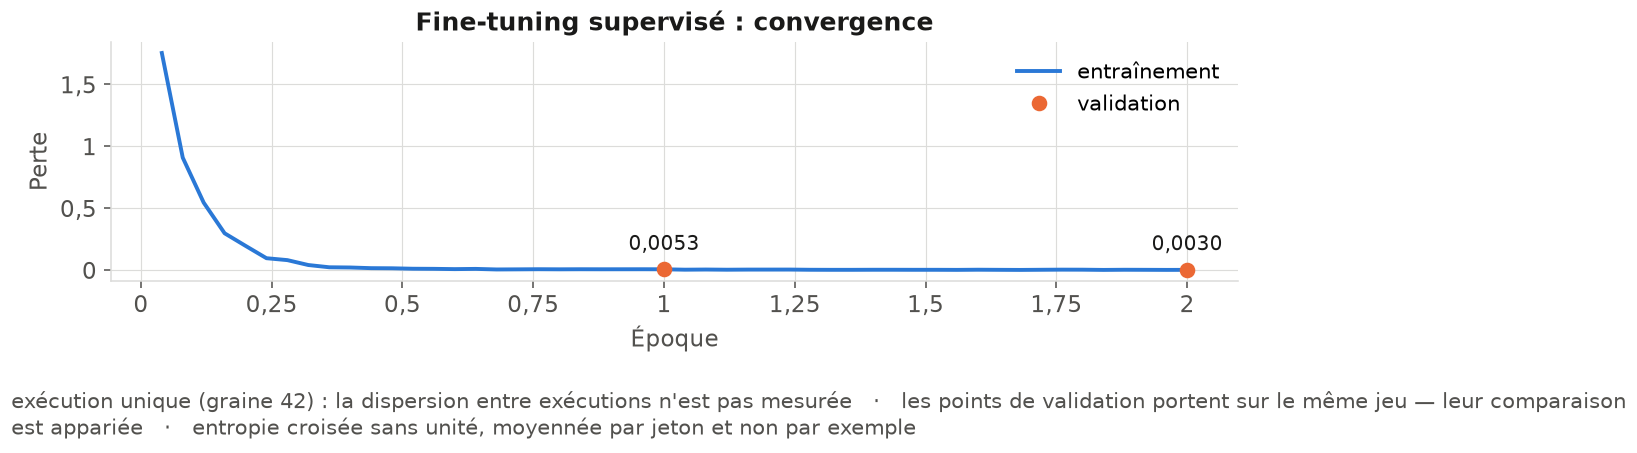

perte d'entrainement finale : 0.0826
perte de validation finale  : 0.0030


In [11]:
if sft:
    path = figures.sft_training(sft["history"], PATHS.figures / "sft_training.png")
    plt.close("all")
    display(Image(str(path)))

    print(f"final training loss   : {sft['metrics']['train_loss']:.4f}")
    print(f"final validation loss : {sft['metrics']['eval_loss']:.4f}")

The gap between the two losses stays small: the model has not learnt the corpus by heart. The
best validation point is kept at the end of training in preference to the last one, for the same
reason.

In [12]:
if sft:
    print("hyper-parameters actually used:")
    for key, value in sft["hyperparameters"].items():
        print(f"  {key:24s} : {value}")

hyperparametres reellement utilises :
  modele_de_base           : Qwen/Qwen3-1.7B-Base
  moteur                   : unsloth
  epochs                   : 2
  batch_size               : 4
  grad_accum               : 4
  lot_effectif             : 16
  learning_rate            : 0.0002
  lora_r                   : 32
  lora_alpha               : 64
  lora_dropout             : 0.05
  lora_modules             : q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj, lm_head
  max_length               : 768
  gradient_checkpointing   : True
  max_steps                : -1
  graine                   : 42


These are the values **actually used**, logged by the training run itself, and not the defaults
of the configuration. This file is what the published figures rest on.

## 6. Qualitative check

Three cases, one of them a trap: a patient who plays down what he feels.

In [13]:
from clinical_triage.inference import TriageAgent

agent = TriageAgent(adapter_dir=PATHS.sft_adapter, base_model=MODEL.base_model)

cases = [
    "Homme de 67 ans, douleur thoracique constrictive et sueurs depuis 20 minutes. TA 148/92, FC 102.",
    "Femme de 34 ans, nez bouché et mal de gorge depuis deux jours, pas de fièvre.",
    (
        "Homme de 19 ans asthmatique : « ma poitrine est un peu serrée, rien de grave ». "
        "Il parle par phrases courtes. SpO2 90 %, FR 32."
    ),
]
for answer, description in zip(agent.generate_batch(cases), cases, strict=True):
    print(description)
    print(f"  -> {answer.text}")
    print(f"  ({answer.generated_tokens} tokens, clean stop: {answer.clean_stop})")
    print()

2026-09-17 10:37:35,515 | INFO    | inference | Chargement du modèle Qwen/Qwen3-1.7B-Base sur cuda (unsloth)


unsloth/__init__.py:1554: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0917 10:37:36.116000 29748 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0917 10:37:36.159000 29748 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


...

2026-09-17 10:37:45,985 | INFO    | inference | Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-sft


[inference|INFO]Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-sft


peft/tuners/tuners_utils.py:1463: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Homme de 67 ans, douleur thoracique constrictive et sueurs depuis 20 minutes. TA 148/92, FC 102.
  -> Niveau de priorité : URGENCE_VITALE
Justification : Douleur thoracique constrictive avec irradiation brachiale et sueurs : tableau évocateur d'un syndrome coronarien aigu, dont le pronostic dépend du délai de reperfusion.
Recommandation : Prise en charge immédiate en salle de déchocage, électrocardiogramme dans les dix minutes, appel du cardiologue et du 15 (SAMU) si la prise en charge ne peut être immédiate.
  (117 jetons, arret propre : True)

Femme de 34 ans, nez bouche et mal de gorge depuis deux jours, pas de fievre.
  -> Niveau de priorité : CONSULTATION_DIFFEREE
Justification : Infection virale bénigne des voies aériennes supérieures, sans fièvre ni signe respiratoire de gravité : aucun critère d'urgence.
Recommandation : Traitement symptomatique et lavages de nez, consultation chez le médecin traitant si les symptômes persistent au-delà de dix jours ou si une fièvre apparaît.
 

In [14]:
del agent
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Where that leaves the model

- The format trap was the root cause of the degraded answers: a re-serialised template and an
  unsuitable end token. The correction propagates to every stage of the project.
- LoRA trains a fraction of the model, and the run fits on a 16 GB card.
- Four settings were compared on the loss **and** on triage accuracy; the one kept is the one
  that decides correctly, not the one that minimises the loss.
- The gap between training loss and validation loss stays small.

Next: notebook 03 aligns this model on clinical safety preferences.